In [181]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import os
import re
import matplotlib.image as mpimg

In [274]:
# Path to your saved evaluation results
PICKLE_PATH = "eval_results.pkl"

ORIGINAL_PATH = "original_results.pkl"

# Load the evaluation results
with open(PICKLE_PATH, "rb") as f:
    results = pickle.load(f)

with open(ORIGINAL_PATH, "rb") as f:
    original_results = pickle.load(f)

####################
## ST-GRU METRICS ##
####################
# Extract metrics
iterations = results["iterations"]
losses = results["losses"]
mse_frame = results["mse_frame"]
ssim = results["ssim"]
psnr = results["psnr"]
lpips = results["lpips"]

# Metrics of final model
final_mse = mse_frame[-1]
final_ssim = ssim[-1]
final_psnr = psnr[-1]
final_lpips = lpips[-1]

# Averages per frame
mse_avg = [np.mean(x) for x in mse_frame]
ssim_avg = [np.mean(x) for x in ssim]
psnr_avg = [np.mean(x) for x in psnr]
lpips_avg = [np.mean(x) for x in lpips]

print('ST-GRU metrics:')
print(f'mse: {np.mean(final_mse):.1f}')
print(f'ssim: {np.mean(final_ssim):.3f}')
print(f'psnr: {np.mean(final_psnr):.3f}')
print(f'lpips: {np.mean(final_lpips):.3f}')
print()

#####################
## ST-LSTM METRICS ##
#####################
# Extract original metrics (already of final model!)
orig_mse = original_results["mse_frame"]
orig_ssim = original_results["ssim"]  
orig_psnr = original_results["psnr"]
orig_lpips = original_results["lpips"]


print('ST-LSTM metrics:')
print(f'mse: {np.mean(orig_mse):.1f}')
print(f'ssim: {np.mean(orig_ssim):.3f}')
print(f'psnr: {np.mean(orig_psnr):.3f}')
print(f'lpips: {np.mean(orig_lpips):.3f}')

ST-GRU metrics:
mse: 55.1
ssim: 0.883
psnr: 19.529
lpips: 0.065

ST-LSTM metrics:
mse: 48.8
ssim: 0.892
psnr: 20.047
lpips: 0.066


In [269]:
len(orig_psnr)

10

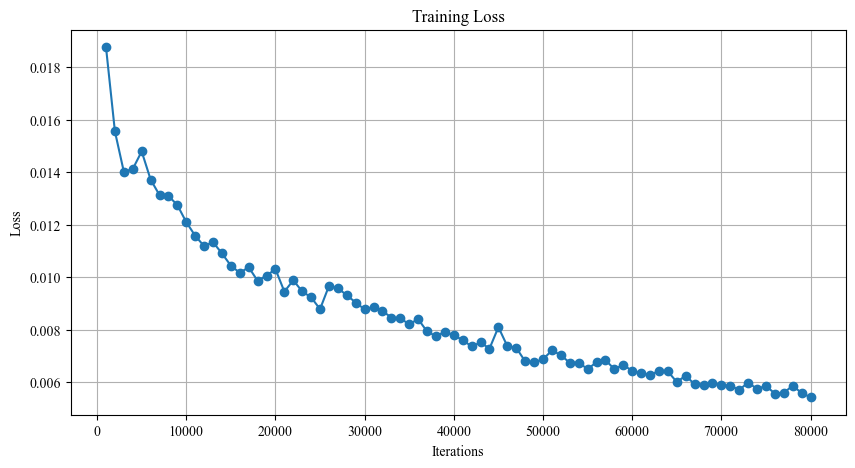

In [183]:
plt.figure(figsize=(10, 5))
plt.plot(iterations, losses, marker='o', color='tab:blue')
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

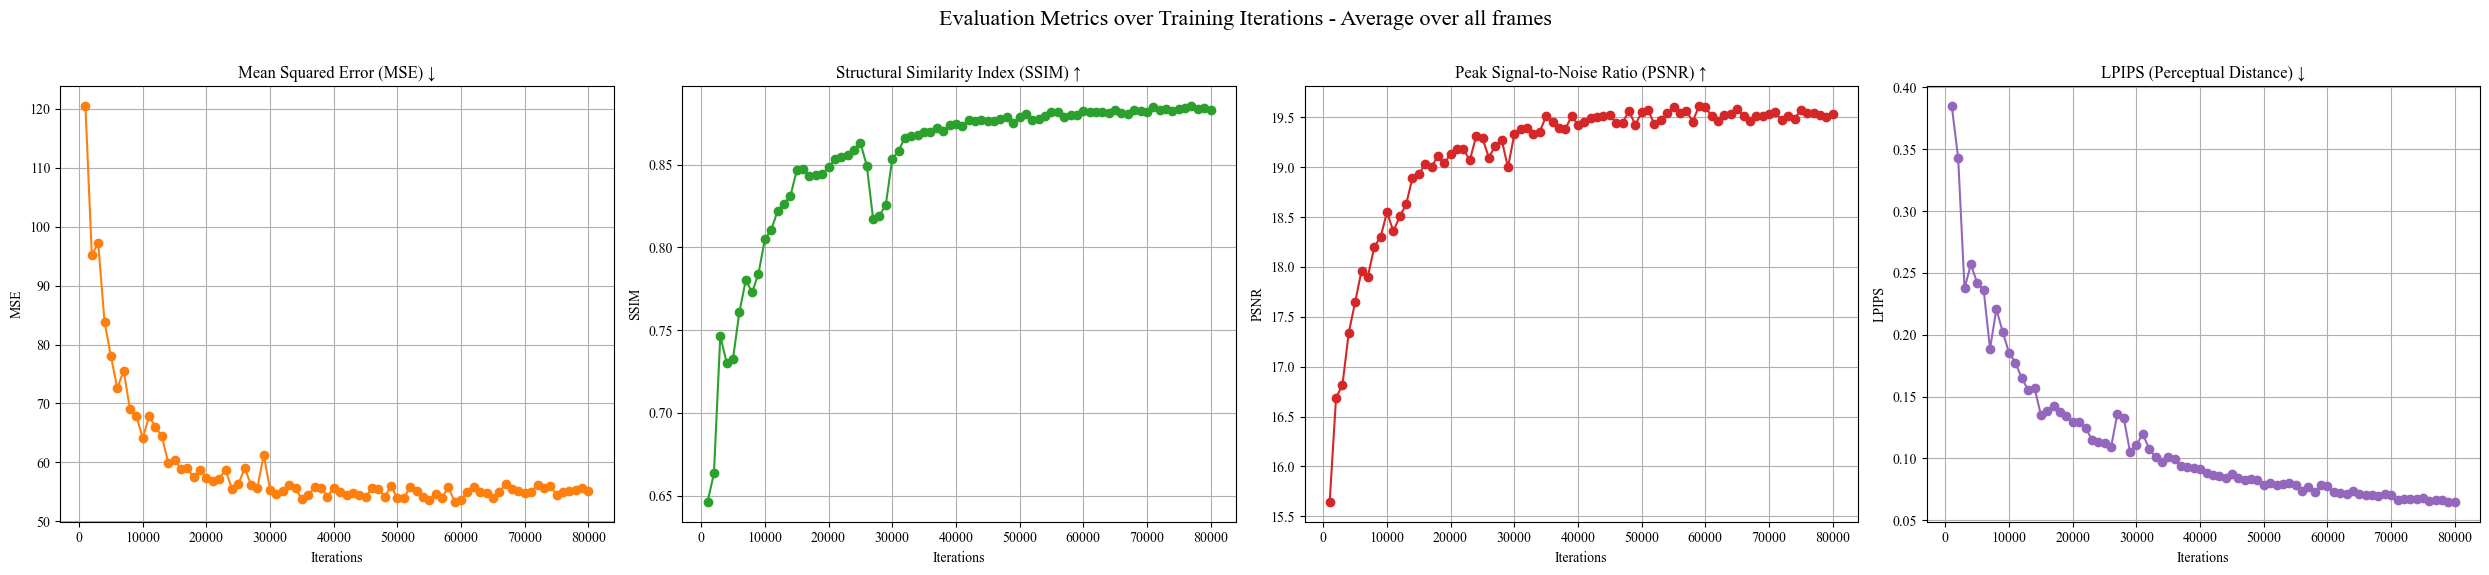

In [ ]:
fig, axs = plt.subplots(1, 4, figsize=(25, 6))
fig.suptitle("Evaluation Metrics over Training Iterations - Average over all frames", fontsize=16)

# Plot MSE (averaged)
axs[0].plot(iterations, mse_avg, marker='o', color='tab:orange')
axs[0].set_title("Mean Squared Error (MSE) ↓")
axs[0].set_xlabel("Iterations")
axs[0].set_ylabel("MSE")
axs[0].grid(True)

# Plot SSIM (averaged)
axs[1].plot(iterations, ssim_avg, marker='o', color='tab:green')
axs[1].set_title("Structural Similarity Index (SSIM) ↑")
axs[1].set_xlabel("Iterations")
axs[1].set_ylabel("SSIM")
axs[1].grid(True)

# Plot PSNR (averaged)
axs[2].plot(iterations, psnr_avg, marker='o', color='tab:red')
axs[2].set_title("Peak Signal-to-Noise Ratio (PSNR) ↑")
axs[2].set_xlabel("Iterations")
axs[2].set_ylabel("PSNR")
axs[2].grid(True)

# Plot LPIPS (averaged)
axs[3].plot(iterations, lpips_avg, marker='o', color='tab:purple')
axs[3].set_title("Perceptual Distance (LPIPS) ↓")
axs[3].set_xlabel("Iterations")
axs[3].set_ylabel("LPIPS")
axs[3].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()


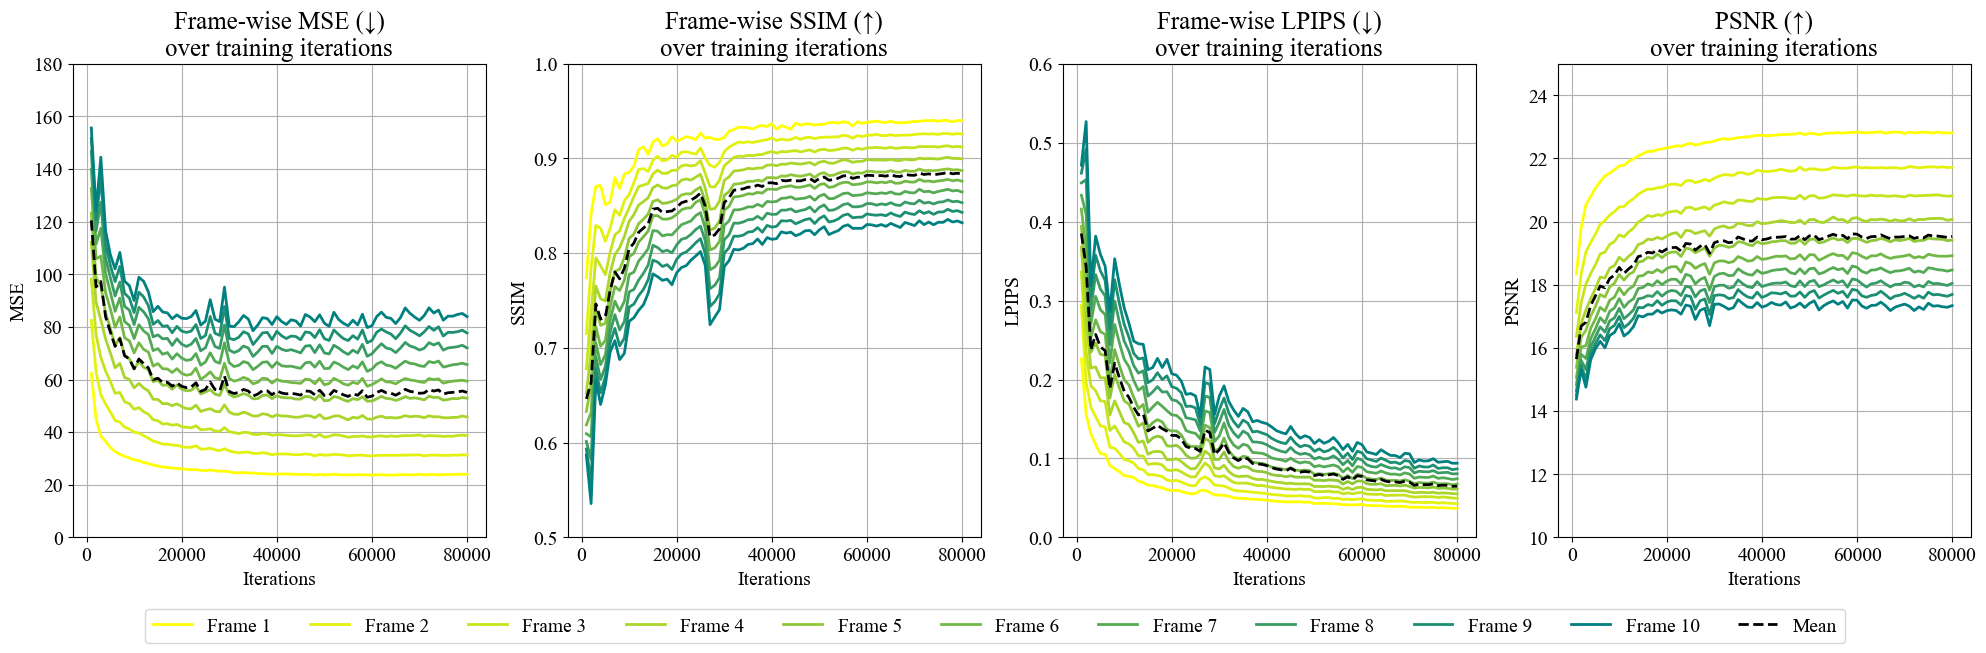

In [215]:
colors = [(1.0, 1.0, 0.0, 1.0),
 (0.8889, 0.9447, 0.0558, 1.0),
 (0.7778, 0.8893, 0.1115, 1.0),
 (0.6667, 0.8340, 0.1673, 1.0),
 (0.5556, 0.7786, 0.2231, 1.0),
 (0.4444, 0.7233, 0.2789, 1.0),
 (0.3333, 0.6680, 0.3346, 1.0),
 (0.2222, 0.6126, 0.3904, 1.0),
 (0.1111, 0.5573, 0.4462, 1.0),
 (0.0, 0.5020, 0.5020, 1.0)]
plt.rcParams["font.family"] = "Times New Roman"

fig, axs = plt.subplots(1, 4, figsize=(20, 7))
#fig.suptitle("Evaluation Metrics over Training Iterations per Frame", fontsize=16)

# Plot MSE
for i in range(10):
    axs[0].plot(iterations, np.array(mse_frame)[:,i], color=colors[i], label=f"Frame {i+1}", linewidth=2, alpha=1)
axs[0].plot(iterations, mse_avg, color='k', linewidth=2, linestyle='--', label="Mean")
axs[0].set_title("Frame-wise MSE (↓)\nover training iterations", fontsize=18)
axs[0].set_xlabel("Iterations", fontsize=14)
axs[0].set_ylabel("MSE", fontsize=14)
axs[0].set_ylim(0, 180)
axs[0].tick_params(axis='both', labelsize=14)
axs[0].grid(True)

# Plot SSIM
for i in range(10):
    axs[1].plot(iterations, np.array(ssim)[:,i], color=colors[i], label=f"Frame {i+1}", linewidth=2, alpha=1)
axs[1].plot(iterations, ssim_avg, color='k', linewidth=2, linestyle='--', label="Mean")
axs[1].set_title("Frame-wise SSIM (↑)\nover training iterations", fontsize=18)
axs[1].set_xlabel("Iterations", fontsize=14)
axs[1].set_ylabel("SSIM", fontsize=14)
axs[1].set_ylim(0.5, 1)
axs[1].tick_params(axis='both', labelsize=14)
axs[1].grid(True)

# Plot LPIPS
for i in range(10):
    axs[2].plot(iterations, np.array(lpips)[:,i], color=colors[i], label=f"Frame {i+1}", linewidth=2, alpha=1)
axs[2].plot(iterations, lpips_avg, color='k', linewidth=2, linestyle='--', label="Mean")
axs[2].set_title("Frame-wise LPIPS (↓)\nover training iterations", fontsize=18)
axs[2].set_xlabel("Iterations", fontsize=14)
axs[2].set_ylabel("LPIPS", fontsize=14)
axs[2].set_ylim(0, 0.6)
axs[2].tick_params(axis='both', labelsize=14)
axs[2].grid(True)

# Plot PSNR
for i in range(10):
    axs[3].plot(iterations, np.array(psnr)[:,i], color=colors[i], label=f"Frame {i+1}", linewidth=2, alpha=1)
axs[3].plot(iterations, psnr_avg, color='k', linewidth=2, linestyle='--', label="Mean")
axs[3].set_title("PSNR (↑)\nover training iterations", fontsize=18)
axs[3].set_xlabel("Iterations", fontsize=14)
axs[3].set_ylabel("PSNR", fontsize=14)
axs[3].set_ylim(10, 25)
axs[3].tick_params(axis='both', labelsize=14)
axs[3].grid(True)


handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=11, bbox_to_anchor=(0.5, 0.03), fontsize=14)

plt.tight_layout(rect=[0, 0.1, 1, 0.97]) 
plt.show()

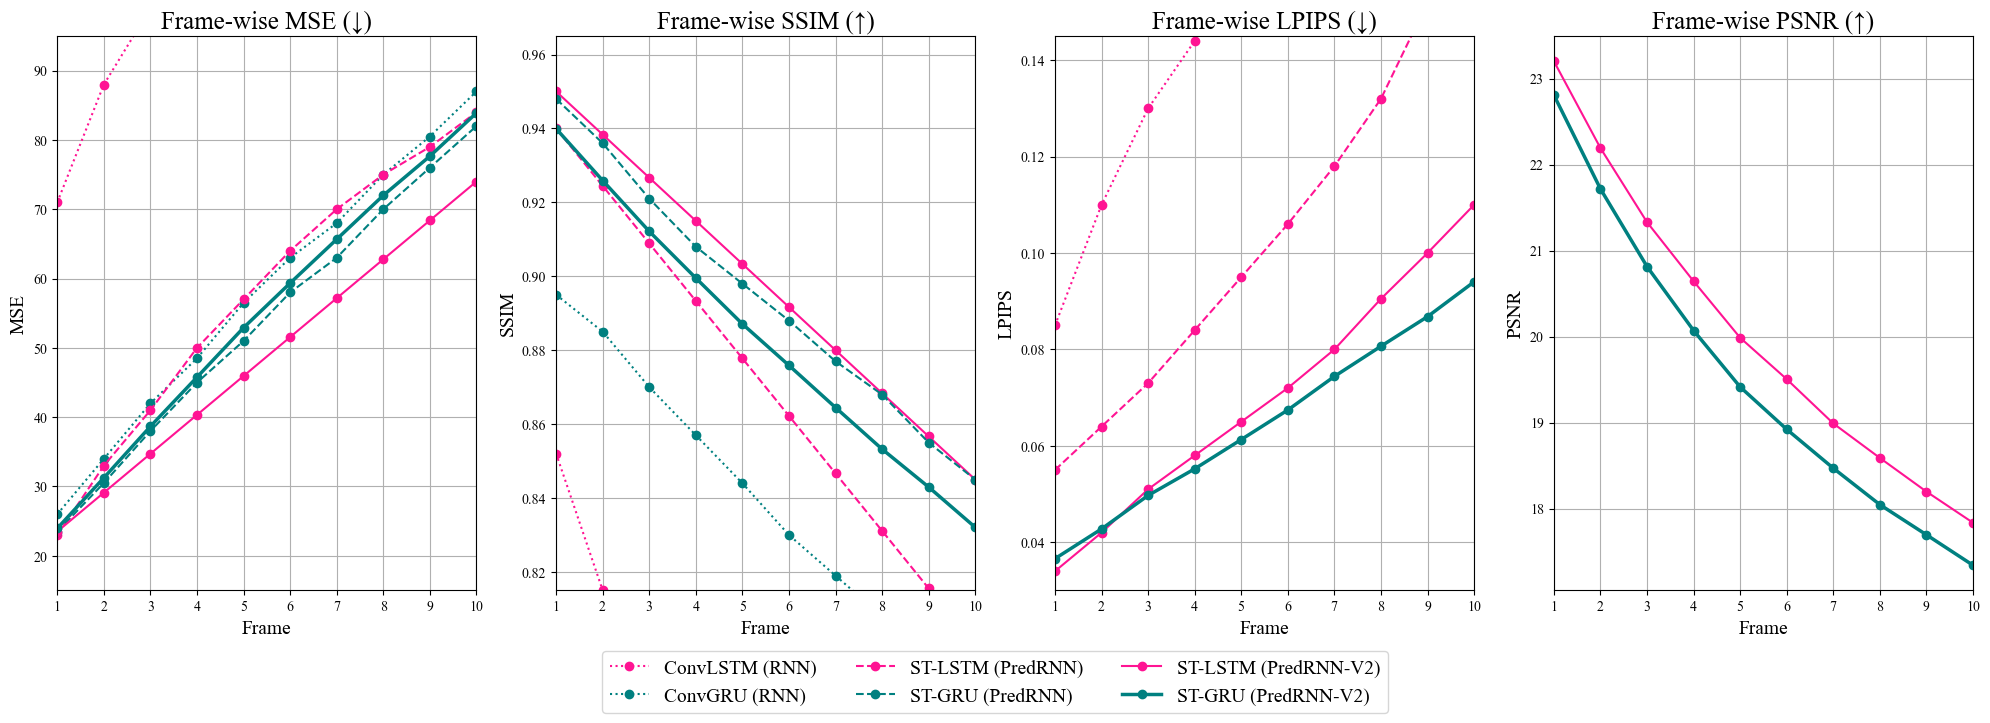

In [277]:
color_LSTM = ['deeppink','deeppink','deeppink']
linestyle_LSTM = [':', '--', '-']
color_GRU = ['teal','teal','teal']
linestyle_GRU = [':', '--', '-']
marker = 'o'


fig, axs = plt.subplots(1, 4, figsize=(20, 7))
#fig.suptitle("Evaluation of Final PredRNN-GRU Model", fontsize=16)

# Plot MSE
axs[0].plot([71,88,99,108,115,120,124,125,124,122], marker=marker, linestyle=linestyle_LSTM[0], color=color_LSTM[0], label="ConvLSTM (RNN)")
axs[0].plot([26,34,42,48.5,56.5,63,68,75,80.5,87], marker=marker, linestyle=linestyle_GRU[0], color=color_GRU[0], label="ConvGRU (RNN)")
#axs[0].plot([24,33,38,45.5,53,58,65,71.5,76,81.5], marker=marker, linestyle=linestyle_LSTM[1], color=color_LSTM[1], label="ST-LSTM (PredRNN)")
axs[0].plot([23,33,41,50,57,64,70,75,79,84], marker=marker, linestyle=linestyle_LSTM[1], color=color_LSTM[1], label="ST-LSTM (PredRNN)")
axs[0].plot([23.5,30.5,38,45,51,58,63,70,76,82], marker=marker, linestyle=linestyle_GRU[1], color=color_GRU[1], label="ST-GRU (PredRNN)")
#axs[0].plot(orig_mse, marker=marker, linestyle=linestyle_LSTM[2], color=color_LSTM[2], label="ST-LSTM (PredRNN-V2)")
axs[0].plot(np.linspace(23.5,74,10), marker=marker, linestyle=linestyle_LSTM[2], color=color_LSTM[2], label="ST-LSTM (PredRNN-V2)")
axs[0].plot(final_mse, marker=marker, linestyle=linestyle_GRU[2], color=color_GRU[2], label="ST-GRU (PredRNN-V2)", linewidth=2.5)
axs[0].set_title("Frame-wise MSE (↓)", fontsize=18)
axs[0].set_xlabel("Frame", fontsize=14)
axs[0].set_ylabel("MSE", fontsize=14)
axs[0].set_ylim(15, 95)
#axs[0].legend(fontsize=14, bbox_to_anchor=(0.5, -0.1), loc='upper center', ncols=1)
axs[0].set_xlim(0, 9)
axs[0].set_xticks(np.arange(0, 10, 1), ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"])
axs[0].grid(True)

# Plot SSIM
axs[1].plot([0.852,0.815,0.775,0.742,0.718,0.684,0.65,0.63,0.615,0.605], marker=marker, linestyle=linestyle_LSTM[0], color=color_LSTM[0], label="ConvLSTM (RNN)")
#axs[1].plot([0.935,0.92,0.907,0.895,0.885,0.874,0.862,0.85,0.84,0.828], marker=marker, linestyle=linestyle_LSTM[1], color=color_LSTM[1], label="ST-LSTM (PredRNN)")
axs[1].plot(np.linspace(0.94,0.8,10), marker=marker, linestyle=linestyle_LSTM[1], color=color_LSTM[1], label="ST-LSTM (PredRNN)")
#axs[1].plot(orig_ssim, marker=marker, linestyle=linestyle_LSTM[2], color=color_LSTM[2], label="ST-LSTM (PredRNN-V2)")
axs[1].plot(np.linspace(0.95,0.845,10), marker=marker, linestyle=linestyle_LSTM[2], color=color_LSTM[2], label="ST-LSTM (PredRNN-V2)")
axs[1].plot([0.895,0.885,0.87,0.857,0.844,0.83,0.819,0.808,0.795,0.78], marker=marker, linestyle=linestyle_GRU[0], color=color_GRU[0], label="ConvGRU (RNN)")
axs[1].plot([0.948,0.936,0.921,0.908,0.898,0.888,0.877,0.868,0.855,0.845], marker=marker, linestyle=linestyle_GRU[1], color=color_GRU[1], label="ST-GRU (PredRNN)")
axs[1].plot(final_ssim, marker=marker, linestyle=linestyle_GRU[2], color=color_GRU[2], label="ST-GRU (PredRNN-V2)", linewidth=2.5)
axs[1].set_title("Frame-wise SSIM (↑)", fontsize=18)
axs[1].set_xlabel("Frame", fontsize=14)
axs[1].set_ylabel("SSIM", fontsize=14)
axs[1].set_ylim(0.815,0.965)
axs[1].set_xlim(0, 9)
#axs[1].legend(fontsize=14, bbox_to_anchor=(0.5, -0.1), loc='upper center', ncols=1)
axs[1].set_xticks(np.arange(0, 10, 1), ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"])
axs[1].grid(True)

# Plot LPIPS (averaged)
axs[2].plot([0.085,0.11,0.13,0.144,0.155,0.165,0.179,0.192,0.209,0.22], marker=marker, linestyle=linestyle_LSTM[0], color=color_LSTM[0], label="ConvLSTM")
axs[2].plot([0.055,0.064,0.073,0.084,0.095,0.106,0.118,0.132,0.152,0.168], marker=marker, linestyle=linestyle_LSTM[1], color=color_LSTM[1], label="ST-LSTM (PredRNN)")
#axs[2].plot(orig_lpips, marker=marker, linestyle=linestyle_LSTM[2], color=color_LSTM[2], label="ST-LSTM (PredRNN-V2)")
axs[2].plot([0.034,0.042,0.051,0.058,0.065,0.072,0.080,0.0905,0.10,0.110], marker=marker, linestyle=linestyle_LSTM[2], color=color_LSTM[2], label="ST-LSTM (PredRNN-V2)")
axs[2].plot(final_lpips, marker=marker, linestyle=linestyle_GRU[2], color=color_GRU[2], label="ST-GRU (PredRNN-V2)", linewidth=2.5)
axs[2].set_title("Frame-wise LPIPS (↓)", fontsize=18)
axs[2].set_xlabel("Frame", fontsize=14)
axs[2].set_ylabel("LPIPS", fontsize=14)
axs[2].grid(True)
axs[2].set_xlim(0, 9)
axs[2].set_ylim(0.03,0.145)
#axs[2].legend(fontsize=14, bbox_to_anchor=(0.5, -0.1), loc='upper center', ncols=1)
axs[2].set_xticks(np.arange(0, 10, 1), ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"])

# Plot PSNR (averaged)
axs[3].plot(orig_psnr, marker=marker, linestyle=linestyle_LSTM[2], color=color_LSTM[2], label="ST-LSTM (PredRNN-V2)")
axs[3].plot(final_psnr, marker=marker, linestyle=linestyle_GRU[2], color=color_GRU[2], label="ST-GRU (PredRNN-V2)", linewidth=2.5)
axs[3].set_title("Frame-wise PSNR (↑)", fontsize=18)
axs[3].set_xlabel("Frame", fontsize=14)
axs[3].set_ylabel("PSNR", fontsize=14)
axs[3].grid(True)
axs[3].set_xlim(0, 9)
#axs[3].legend(fontsize=14, bbox_to_anchor=(0.5, -0.1), loc='upper center', ncols=1)
axs[3].set_xticks(np.arange(0, 10, 1), ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10"])

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.07), fontsize=14)
plt.show()

In [262]:
print(np.mean(final_psnr))
print(np.mean(orig_psnr))

19.529324
20.046688


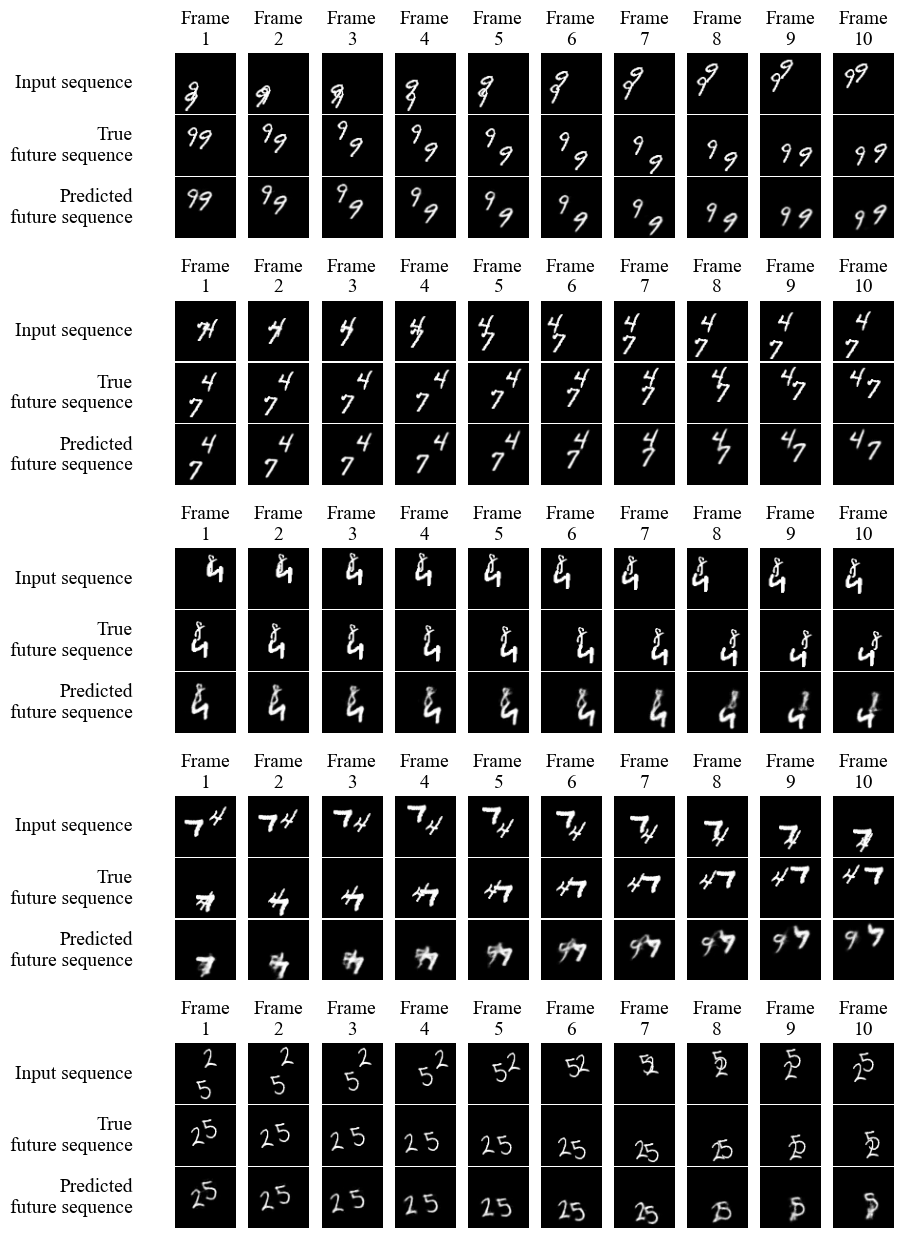

In [259]:
base_path = "results/mnist_predrnn_gru_final_2/58000"

def natural_key(filename):
    return [int(s) if s.isdigit() else s for s in re.split(r'(\d+)', filename)]

num_sequences = 5
frames_per_row = 10
rows_per_seq = 3
spacer_rows = 1  # add 1 empty row between sequences

total_rows = num_sequences * rows_per_seq + (num_sequences - 1) * spacer_rows

row_labels = ["Input sequence", "True\nfuture sequence", "Predicted\nfuture sequence"]
label_fontsize = 14
title_fontsize = 14

fig_height = 2.5 * num_sequences  # adjust as needed

fig, axs = plt.subplots(total_rows, frames_per_row + 1, figsize=(20, fig_height))
fig.subplots_adjust(hspace=0.02, wspace=0.05, top=0.97, bottom=0.03, left=0.5)

for seq_idx in range(num_sequences):
    folder = os.path.join(base_path, str(seq_idx + 1))

    gt_images = sorted([f for f in os.listdir(folder) if "gt" in f and f.endswith(".png")], key=natural_key)
    pred_images = sorted([f for f in os.listdir(folder) if "pd" in f and f.endswith(".png")], key=natural_key)
    assert len(gt_images) == 20, f"Expected 20 GT images in {folder}"
    assert len(pred_images) == 10, f"Expected 10 predicted images in {folder}"

    gt_imgs = [mpimg.imread(os.path.join(folder, f)) for f in gt_images]
    pred_imgs = [mpimg.imread(os.path.join(folder, f)) for f in pred_images]

    base_row = seq_idx * (rows_per_seq + spacer_rows)

    for r in range(rows_per_seq):
        for t in range(frames_per_row):
            if r == 0:
                img = gt_imgs[t]
            elif r == 1:
                img = gt_imgs[t + 10]
            else:
                img = pred_imgs[t]
            axs[base_row + r, t + 1].imshow(img, cmap='gray')
            axs[base_row + r, t + 1].axis('off')

    for r in range(rows_per_seq):
        ax_label = axs[base_row + r, 0]
        ax_label.axis('off')
        ax_label.text(0.5, 0.5, row_labels[r], ha='right', va='center', fontsize=label_fontsize)

# Turn off spacer rows (empty rows between sequences)
for spacer_idx in range(num_sequences - 1):
    spacer_row = (spacer_idx + 1) * (rows_per_seq + spacer_rows) - spacer_rows
    for ax in axs[spacer_row, :]:
        ax.axis('off')

# Add column titles only once on top rows of each sequence (skip label col 0)
for t in range(frames_per_row):
    for s in range(num_sequences):
        row_idx = s * (rows_per_seq + spacer_rows)
        axs[row_idx, t + 1].set_title(f"Frame\n{t + 1}", fontsize=label_fontsize)

plt.show()


In [264]:
orig_final_ssim

0.84373194